**🌐 Language:** **English** | [한국어 →](/regression/05-the-unreasonable-effectiveness-of-linear-regression-minimal-ko)

# The Unreasonable Effectiveness of Linear Regression (Minimal)

If treatment is randomized, linear regression is a very efficient way to recover the same idea as a group mean difference in an RCT or A/B test. For non-random data, we need more caution: we should first look at how variables are related and ask what important variables might still be omitted, because omitted-variable bias (OVB) can remain.


In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")


## Load Data

We focus only on `wage.csv`.


In [2]:
wage = pd.read_csv("data/wage.csv").dropna().copy()
wage["hwage"] = wage["wage"] / wage["hours"]

wage[["wage", "hours", "hwage", "lhwage", "educ", "IQ", "exper", "tenure", "age"]].head()


,wage,hours,hwage,lhwage,educ,IQ,exper,tenure,age
0,769,40,19.225,2.956212,12,93,11,2,31
2,825,40,20.625,3.026504,14,108,11,9,33
3,650,40,16.250,2.788093,12,96,13,7,32
4,562,40,14.050,2.642622,11,74,14,5,34
6,600,40,15.000,2.708050,10,91,13,0,30


## Check Relationships First

Before treating regression as causal in observational data, it helps to inspect how education, wages, ability proxies, and background variables move together.


In [3]:
key_vars = ["lhwage", "educ", "IQ", "exper", "tenure", "age", "meduc", "feduc"]
wage[key_vars].corr().round(2)


,lhwage,educ,IQ,exper,tenure,age,meduc,feduc
lhwage,1.00,0.27,0.27,0.06,0.17,0.18,0.20,0.20
educ,0.27,1.00,0.54,-0.45,-0.03,0.05,0.36,0.42
IQ,0.27,0.54,1.00,-0.23,0.02,-0.02,0.32,0.34
exper,0.06,-0.45,-0.23,1.00,0.29,0.47,-0.16,-0.25
tenure,0.17,-0.03,0.02,0.29,1.00,0.28,0.01,-0.04
age,0.18,0.05,-0.02,0.47,0.28,1.00,0.01,-0.06
meduc,0.20,0.36,0.32,-0.16,0.01,0.01,1.00,0.58
feduc,0.20,0.42,0.34,-0.25,-0.04,-0.06,0.58,1.00


## Analyze

Start with a simple regression, then add plausible controls. The gap between them is a practical reminder that observational estimates depend on what we control for.


In [4]:
simple_model = smf.ols("lhwage ~ educ", data=wage).fit()

controls = [
    "IQ", "exper", "tenure", "age", "married", "black",
    "south", "urban", "sibs", "brthord", "meduc", "feduc"
]
controlled_model = smf.ols(
    "lhwage ~ educ + " + " + ".join(controls),
    data=wage,
).fit()

pd.DataFrame(
    {
        "coef_on_educ": [simple_model.params["educ"], controlled_model.params["educ"]],
        "p_value": [simple_model.pvalues["educ"], controlled_model.pvalues["educ"]],
        "ci_low": [simple_model.conf_int().loc["educ", 0], controlled_model.conf_int().loc["educ", 0]],
        "ci_high": [simple_model.conf_int().loc["educ", 1], controlled_model.conf_int().loc["educ", 1]],
    },
    index=["Simple", "Controlled"],
).round(4)


,coef_on_educ,p_value,ci_low,ci_high
Simple,0.0536,0.0000,0.0388,0.0684
Controlled,0.0411,0.0001,0.0213,0.0610


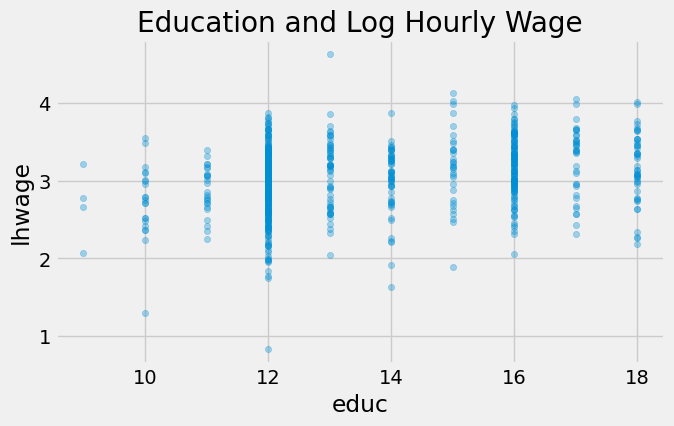

In [5]:
ax = wage.plot.scatter(x="educ", y="lhwage", alpha=0.35, figsize=(7, 4))
ax.set_title("Education and Log Hourly Wage")
plt.show()


## Result

In a randomized setting, regression is often just a compact way to estimate the same treatment contrast as a difference in group means. Here, the wage data are observational, so the regression coefficient on `educ` is more fragile.

Once we add controls, the estimate changes, which suggests that relationships with other variables matter. Even then, the result is not automatically causal, because unobserved factors such as family wealth, ambition, or other ability measures may still create omitted-variable bias.
